# Description Ablation — ChatTS-8B vs Qwen3-VL-8B · 122 UCR Datasets

**Experiment:** `desc_ablation_full`  
**Setup:** random picking · k=1 · 3 seeds (0, 3, 6) · 122 fixed-length UCR datasets · 150 samples

| Condition | Model | `use_label_desc` |
|---|---|---|
| **ChatTS · No Desc** | `bytedance-research/ChatTS-8B` | 0 |
| **ChatTS · With Desc** | `bytedance-research/ChatTS-8B` | 1 |
| **QwenVL · No Desc** | `Qwen/Qwen3-VL-8B-Instruct` | 0 |
| **QwenVL · With Desc** | `Qwen/Qwen3-VL-8B-Instruct` | 1 |

**Sections:**
1. Load data from W&B
2. Full 4-way comparison (table + heatmap + winner counts)
3. Per-model description effect (Δ bar charts, scatter, Wilcoxon test)
4. Cross-model comparison at macro level
5. Critical Difference diagram (Friedman + Wilcoxon + Holm–Bonferroni)

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, networkx
from pathlib import Path
from scipy.stats import wilcoxon, friedmanchisquare, spearmanr
from tqdm.auto import tqdm
import sys, os

if wandb.api.api_key is None:
    for folder in ["", "wandb_logger", "logger"]:
        token_path = Path(folder) / "token.txt"
        if token_path.exists():
            wandb.login(key=token_path.read_text().strip())
            break

ENTITY  = "aviramom-"
PROJECT = "ts-icl"          # new project used by desc_ablation_full
EXP_ID  = "desc_ablation_full"

CHATTS_MODEL = "bytedance-research/ChatTS-8B"
QWENVL_MODEL = "Qwen/Qwen3-VL-8B-Instruct"

COND_CHATTS_NO   = "ChatTS · No Desc"
COND_CHATTS_WITH = "ChatTS · With Desc"
COND_VL_NO       = "QwenVL · No Desc"
COND_VL_WITH     = "QwenVL · With Desc"
CONDITIONS       = [COND_CHATTS_NO, COND_CHATTS_WITH, COND_VL_NO, COND_VL_WITH]

N_SEEDS = 3   # seeds 0, 3, 6

api = wandb.Api(timeout=60)
print(f"Connected to {ENTITY}/{PROJECT}")
print(f"  Exp ID : {EXP_ID}")

/home/aviramom/.conda/envs/multits/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Connected to aviramom-/ts-icl
  Exp ID : desc_ablation_full


## 1 · Load Data from W&B

Fetches all runs for `desc_ablation_full` and caches locally.
Set `FORCE_REFRESH = True` when new runs finish.

In [2]:
CONFIG_KEYS = ["task_id", "method", "num_samples", "exp_id", "input_mode",
               "num_shots", "random_seed", "picking_strategy", "use_label_desc"]
METRIC_KEYS = ["balanced_accuracy", "f1_macro", "f1_weighted",
               "num_of_classes", "total_test_size", "flawed_count", "flawed_percentage"]

CACHE_PATH    = Path("cache_desc_ablation_full.parquet")
FORCE_REFRESH = True   # flip to True when new runs finish

def get_val(cfg, summary, key):
    return summary.get(key, cfg.get(key))

def fetch_exp(exp_id, cache_path):
    if cache_path.exists() and not FORCE_REFRESH:
        df = pd.read_parquet(cache_path)
        print(f"Loaded {len(df)} rows from cache ({cache_path})")
        return df
    all_runs = list(api.runs(path=f"{ENTITY}/{PROJECT}", per_page=1000))
    rows = []
    for run in tqdm(all_runs, desc=f"Processing {exp_id}"):
        summary = {k: v for k, v in (run.summary or {}).items() if not k.startswith("_")}
        cfg     = run.config or {}
        if get_val(cfg, summary, "exp_id") != exp_id:
            continue
        row = {"run_id": run.id, "run_name": run.name, "state": run.state}
        for k in CONFIG_KEYS:
            row[k] = get_val(cfg, summary, k)
        for k in METRIC_KEYS:
            row[k] = get_val(cfg, summary, k)
        rows.append(row)
    df = pd.DataFrame(rows)
    for col in METRIC_KEYS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df.to_parquet(cache_path)
    print(f"Cached {len(df)} rows → {cache_path}")
    return df

df_raw = fetch_exp(EXP_ID, CACHE_PATH)

def assign_condition(row):
    method = str(row.get("method", ""))
    desc   = int(pd.to_numeric(row.get("use_label_desc", 0), errors="coerce") or 0)
    if CHATTS_MODEL in method:
        return COND_CHATTS_WITH if desc else COND_CHATTS_NO
    elif QWENVL_MODEL in method:
        return COND_VL_WITH if desc else COND_VL_NO
    return "Unknown"

df_raw["condition"] = df_raw.apply(assign_condition, axis=1)
df_raw["task"]      = df_raw["task_id"].str.replace("icl_ucr_", "", regex=False)

print(f"\n{'─'*55}")
print(f"Total runs loaded : {len(df_raw)}")
print(f"Finished          : {(df_raw['state'] == 'finished').sum()}")
print(f"\nCondition counts:")
for cond in CONDITIONS:
    n = (df_raw["condition"] == cond).sum()
    nf = ((df_raw["condition"] == cond) & (df_raw["state"] == "finished")).sum()
    print(f"  {cond:25s}: {n:4d} total, {nf:4d} finished")

Processing desc_ablation_full:   0%|          | 0/1464 [00:00<?, ?it/s]

Cached 1464 rows → cache_desc_ablation_full.parquet

───────────────────────────────────────────────────────
Total runs loaded : 1464
Finished          : 1464

Condition counts:
  ChatTS · No Desc         :  366 total,  366 finished
  ChatTS · With Desc       :  366 total,  366 finished
  QwenVL · No Desc         :  366 total,  366 finished
  QwenVL · With Desc       :  366 total,  366 finished


In [3]:
finished = df_raw[df_raw["state"] == "finished"].copy()
tasks    = sorted(finished["task"].unique())

print(f"Datasets present in results : {len(tasks)}")
print(f"Total finished runs         : {len(finished)}")
print()

# Coverage check: each task should have N_SEEDS runs per condition
count_check = finished.pivot_table(
    index="task", columns="condition",
    values="balanced_accuracy", aggfunc="count"
).fillna(0).astype(int)
incomplete = count_check[(count_check < N_SEEDS).any(axis=1)]
print(f"Tasks with < {N_SEEDS} seeds in any condition: {len(incomplete)}")
if len(incomplete) > 0:
    print("Incomplete tasks:")
    display(incomplete)

Datasets present in results : 122
Total finished runs         : 1464

Tasks with < 3 seeds in any condition: 0


## 2 · Full 4-Way Comparison

Balanced accuracy (macro recall) — mean ± std across 3 seeds (0, 3, 6).

In [4]:
mean_p = finished.pivot_table(
    index="task", columns="condition",
    values="balanced_accuracy", aggfunc="mean"
)
std_p = finished.pivot_table(
    index="task", columns="condition",
    values="balanced_accuracy", aggfunc="std"
)

cols   = [c for c in CONDITIONS if c in mean_p.columns]
mean_p = mean_p[cols].reindex(tasks)
std_p  = std_p[cols].reindex(tasks)
mean_p.columns.name = std_p.columns.name = ""

# Delta columns (desc − no_desc) per model — only if both sides exist
DELTA_CHATTS = "Δ ChatTS (with−no)"
DELTA_VL     = "Δ QwenVL (with−no)"
DELTA_COLS   = []
if COND_CHATTS_NO in mean_p.columns and COND_CHATTS_WITH in mean_p.columns:
    mean_p[DELTA_CHATTS] = mean_p[COND_CHATTS_WITH] - mean_p[COND_CHATTS_NO]
    DELTA_COLS.append(DELTA_CHATTS)
if COND_VL_NO in mean_p.columns and COND_VL_WITH in mean_p.columns:
    mean_p[DELTA_VL] = mean_p[COND_VL_WITH] - mean_p[COND_VL_NO]
    DELTA_COLS.append(DELTA_VL)

macro = mean_p.mean(axis=0); macro.name = "Macro Avg"
mean_p = pd.concat([mean_p, macro.to_frame().T])
mean_p.index.name = "Task"

print(f"Conditions present: {cols}")
print(f"Delta cols        : {DELTA_COLS}")

# Formatted table (mean ± std for condition cols)
fmt = mean_p.copy().astype(object)
for col in mean_p.columns:
    for idx in mean_p.index:
        m_val = mean_p.loc[idx, col]
        if col not in DELTA_COLS and idx != "Macro Avg" and col in std_p.columns and idx in std_p.index:
            s_val = std_p.loc[idx, col]
            fmt.loc[idx, col] = f"{m_val:.3f} ± {s_val:.3f}" if pd.notna(m_val) else "—"
        else:
            fmt.loc[idx, col] = f"{m_val:.3f}" if pd.notna(m_val) else "—"

print("BALANCED ACCURACY  (mean ± std over 3 seeds)")
display(
    fmt.style
    .set_caption("Balanced Accuracy — ChatTS-8B vs Qwen3-VL-8B · No Desc vs With Desc")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
)

Conditions present: ['ChatTS · No Desc', 'ChatTS · With Desc', 'QwenVL · No Desc', 'QwenVL · With Desc']
Delta cols        : ['Δ ChatTS (with−no)', 'Δ QwenVL (with−no)']
BALANCED ACCURACY  (mean ± std over 3 seeds)


,ChatTS · No Desc,ChatTS · With Desc,QwenVL · No Desc,QwenVL · With Desc,Δ ChatTS (with−no),Δ QwenVL (with−no)
Task,,,,,,
ACSF1,0.190 ± 0.010,0.190 ± 0.010,0.300 ± 0.017,0.300 ± 0.017,0.000,0.000
Adiac,0.052 ± 0.010,0.045 ± 0.009,0.078 ± 0.031,0.082 ± 0.026,-0.007,0.004
AllGestureWiimoteX,0.116 ± 0.009,0.121 ± 0.031,0.180 ± 0.049,0.178 ± 0.027,0.005,-0.001
AllGestureWiimoteY,0.109 ± 0.024,0.148 ± 0.021,0.195 ± 0.012,0.186 ± 0.014,0.039,-0.009
AllGestureWiimoteZ,0.164 ± 0.025,0.120 ± 0.021,0.204 ± 0.036,0.216 ± 0.002,-0.044,0.012
ArrowHead,0.267 ± 0.059,0.266 ± 0.047,0.394 ± 0.084,0.363 ± 0.034,-0.001,-0.030
BME,0.453 ± 0.107,0.482 ± 0.113,0.553 ± 0.110,0.822 ± 0.227,0.029,0.269
Beef,0.156 ± 0.038,0.222 ± 0.077,0.322 ± 0.096,0.344 ± 0.069,0.067,0.022
BeetleFly,0.500 ± 0.000,0.500 ± 0.000,0.500 ± 0.087,0.517 ± 0.161,0.000,0.017


### Balanced Accuracy Heatmap — All 4 Conditions

In [5]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

display(
    tbl[cols].style
    .background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1)
    .format("{:.3f}", na_rep="—")
    .set_caption("Balanced Accuracy — all 4 conditions")
)

vabs = tbl[DELTA_COLS].abs().max().max()
display(
    tbl[DELTA_COLS].style
    .background_gradient(cmap="RdBu", axis=None, vmin=-vabs, vmax=vabs)
    .format("{:+.3f}", na_rep="—")
    .set_caption("Δ per model  (With Desc − No Desc)")
)

,ChatTS · No Desc,ChatTS · With Desc,QwenVL · No Desc,QwenVL · With Desc
Task,,,,
ACSF1,0.190,0.190,0.300,0.300
Adiac,0.052,0.045,0.078,0.082
AllGestureWiimoteX,0.116,0.121,0.180,0.178
AllGestureWiimoteY,0.109,0.148,0.195,0.186
AllGestureWiimoteZ,0.164,0.120,0.204,0.216
ArrowHead,0.267,0.266,0.394,0.363
BME,0.453,0.482,0.553,0.822
Beef,0.156,0.222,0.322,0.344
BeetleFly,0.500,0.500,0.500,0.517


,Δ ChatTS (with−no),Δ QwenVL (with−no)
Task,,
ACSF1,+0.000,+0.000
Adiac,-0.007,+0.004
AllGestureWiimoteX,+0.005,-0.001
AllGestureWiimoteY,+0.039,-0.009
AllGestureWiimoteZ,-0.044,+0.012
ArrowHead,-0.001,-0.030
BME,+0.029,+0.269
Beef,+0.067,+0.022
BeetleFly,+0.000,+0.017


### Completed Runs per (Task, Condition) — target: 3

In [6]:
count_tbl = finished.pivot_table(
    index="task", columns="condition",
    values="balanced_accuracy", aggfunc="count"
).fillna(0).astype(int)
count_tbl = count_tbl[[c for c in CONDITIONS if c in count_tbl.columns]]
count_tbl.index.name = "Task"; count_tbl.columns.name = ""

display(
    count_tbl.style
    .background_gradient(cmap="YlGn", axis=None, vmin=0, vmax=N_SEEDS)
    .set_caption(f"Completed runs per (task, condition) — target: {N_SEEDS}")
)

,ChatTS · No Desc,ChatTS · With Desc,QwenVL · No Desc,QwenVL · With Desc
Task,,,,
ACSF1,3,3,3,3
Adiac,3,3,3,3
AllGestureWiimoteX,3,3,3,3
AllGestureWiimoteY,3,3,3,3
AllGestureWiimoteZ,3,3,3,3
ArrowHead,3,3,3,3
BME,3,3,3,3
Beef,3,3,3,3
BeetleFly,3,3,3,3


### Per-Task Winner and Win Counts

In [7]:
def highlight_winner_row(row):
    styles  = [""] * len(row)
    cond_c  = [c for c in row.index if c not in DELTA_COLS]
    if not cond_c or row[cond_c].isna().all():
        return styles
    best_col = row[cond_c].idxmax()
    for i, col in enumerate(row.index):
        if col == best_col:
            styles[i] = "background-color: #4CAF50; color: white; font-weight: bold"
    return styles

tbl = mean_p.drop(index="Macro Avg", errors="ignore")
display(
    tbl[cols].style
    .apply(highlight_winner_row, axis=1)
    .format("{:.3f}", na_rep="—")
    .set_caption("Winner per task (green) — across all 4 conditions")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
)

winners  = tbl[cols].idxmax(axis=1)
win_cnts = winners.value_counts().reindex(cols, fill_value=0)
total    = len(tbl.dropna(how="all"))
summary  = pd.DataFrame({"Datasets Won": win_cnts, "Win %": (win_cnts / total * 100).round(1)})
summary  = summary.sort_values("Datasets Won", ascending=False)

print(f"\nWin counts — Balanced Accuracy  (out of {total} datasets)")
display(
    summary.style
    .background_gradient(cmap="YlGn", subset=["Datasets Won"], axis=0)
    .format({"Datasets Won": "{:d}", "Win %": "{:.1f}%"})
    .set_caption("# datasets each condition wins")
)

,ChatTS · No Desc,ChatTS · With Desc,QwenVL · No Desc,QwenVL · With Desc
Task,,,,
ACSF1,0.190,0.190,0.300,0.300
Adiac,0.052,0.045,0.078,0.082
AllGestureWiimoteX,0.116,0.121,0.180,0.178
AllGestureWiimoteY,0.109,0.148,0.195,0.186
AllGestureWiimoteZ,0.164,0.120,0.204,0.216
ArrowHead,0.267,0.266,0.394,0.363
BME,0.453,0.482,0.553,0.822
Beef,0.156,0.222,0.322,0.344
BeetleFly,0.500,0.500,0.500,0.517



Win counts — Balanced Accuracy  (out of 122 datasets)


,Datasets Won,Win %
QwenVL · No Desc,70,57.4%
QwenVL · With Desc,35,28.7%
ChatTS · No Desc,10,8.2%
ChatTS · With Desc,7,5.7%


### Macro Average Bar Chart

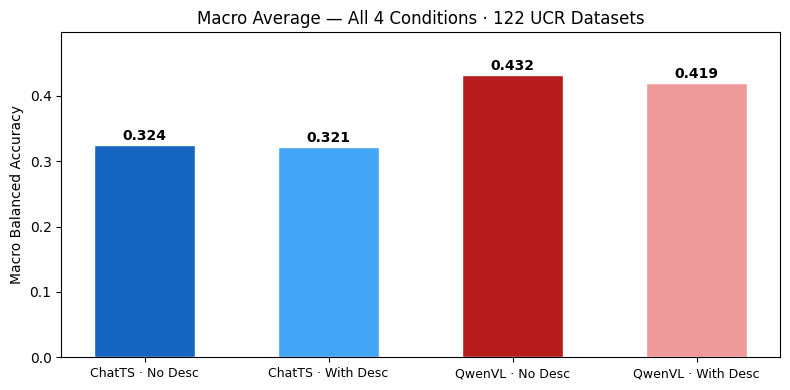

Macro Balanced Accuracy:
  ChatTS · No Desc         : 0.3245
  ChatTS · With Desc       : 0.3213
  QwenVL · No Desc         : 0.4322
  QwenVL · With Desc       : 0.4192


In [8]:
macro_vals = mean_p.loc["Macro Avg", cols]

color_map = {
    COND_CHATTS_NO:   "#1565C0",
    COND_CHATTS_WITH: "#42A5F5",
    COND_VL_NO:       "#B71C1C",
    COND_VL_WITH:     "#EF9A9A",
}
bar_colors = [color_map.get(c, "gray") for c in cols]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cols, macro_vals.values, color=bar_colors, width=0.55, edgecolor="white")
for bar, val in zip(bars, macro_vals.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, max(macro_vals.values) * 1.15)
ax.set_ylabel("Macro Balanced Accuracy")
ax.set_title("Macro Average — All 4 Conditions · 122 UCR Datasets")
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.show()

print("Macro Balanced Accuracy:")
for c in cols:
    print(f"  {c:25s}: {macro_vals[c]:.4f}")

## 3 · Per-Model Description Effect

For each model separately: Δ = With Description − No Description.  
Green bars = description helps; red bars = description hurts.

ChatTS-8B:
  Mean Δ            : -0.0032
  Datasets improved : 47 / 122  (38.5%)
  Datasets hurt     : 49 / 122  (40.2%)
  Datasets tied     : 26 / 122

Qwen3-VL-8B:
  Mean Δ            : -0.0130
  Datasets improved : 40 / 122  (32.8%)
  Datasets hurt     : 69 / 122  (56.6%)
  Datasets tied     : 13 / 122



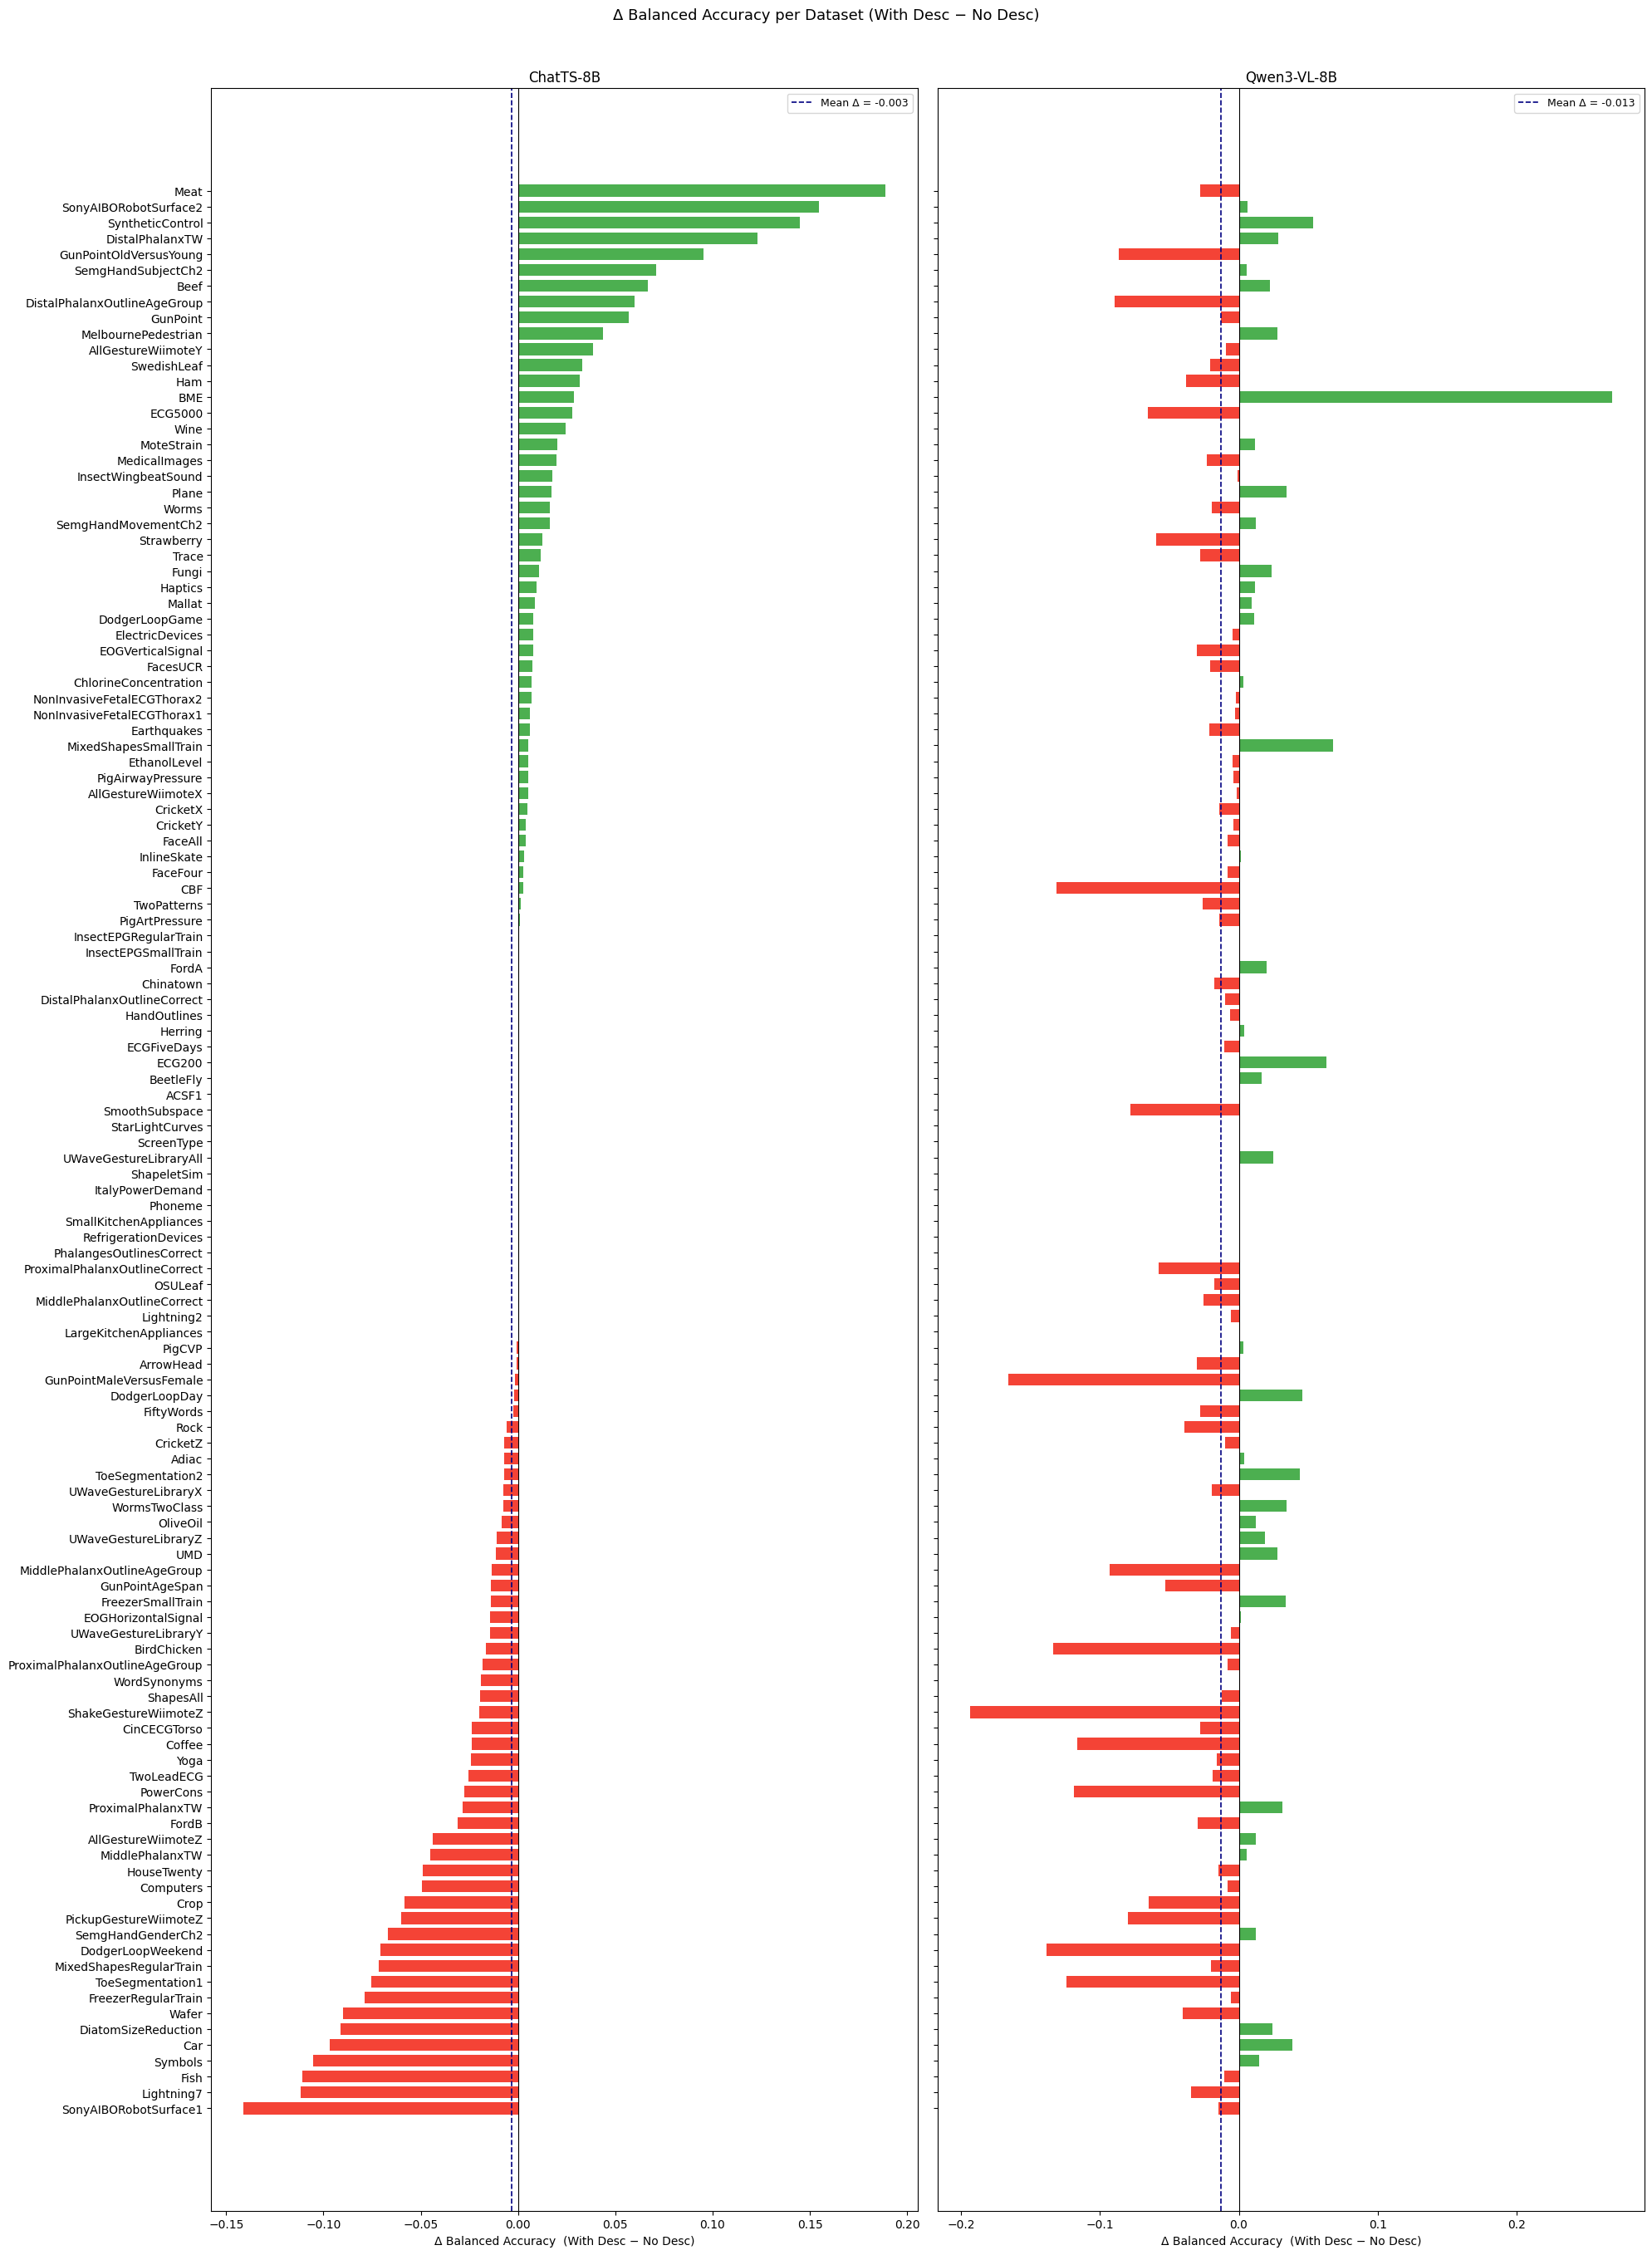

In [9]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

model_pairs = [
    (COND_CHATTS_NO, COND_CHATTS_WITH, "ChatTS-8B",     DELTA_CHATTS),
    (COND_VL_NO,     COND_VL_WITH,     "Qwen3-VL-8B",   DELTA_VL),
]
available = [(a, b, lbl, dcol) for a, b, lbl, dcol in model_pairs if a in tbl.columns and b in tbl.columns]

fig, axes = plt.subplots(1, len(available),
                         figsize=(10 * len(available), max(5, len(tasks) * 0.22)),
                         sharey=True)
if len(available) == 1:
    axes = [axes]

for ax, (cond_a, cond_b, model_label, dcol) in zip(axes, available):
    delta  = (tbl[cond_b] - tbl[cond_a]).dropna().sort_values(ascending=False)
    colors = ["#4CAF50" if v >= 0 else "#F44336" for v in delta]
    ax.barh(delta.index[::-1], delta.values[::-1], color=colors[::-1], height=0.75)
    ax.axvline(0, color="black", linewidth=0.8)
    mean_d = delta.mean()
    ax.axvline(mean_d, color="navy", linewidth=1.2, linestyle="--",
               label=f"Mean Δ = {mean_d:+.3f}")
    ax.set_xlabel("Δ Balanced Accuracy  (With Desc − No Desc)")
    ax.set_title(model_label)
    ax.legend(fontsize=9)

    print(f"{model_label}:")
    print(f"  Mean Δ            : {mean_d:+.4f}")
    print(f"  Datasets improved : {(delta > 0).sum()} / {len(delta)}  ({(delta > 0).mean()*100:.1f}%)")
    print(f"  Datasets hurt     : {(delta < 0).sum()} / {len(delta)}  ({(delta < 0).mean()*100:.1f}%)")
    print(f"  Datasets tied     : {(delta == 0).sum()} / {len(delta)}")
    print()

plt.suptitle("Δ Balanced Accuracy per Dataset (With Desc − No Desc)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### Scatter: No Description vs With Description

Points **above** the diagonal → description helps. Points **below** → description hurts.

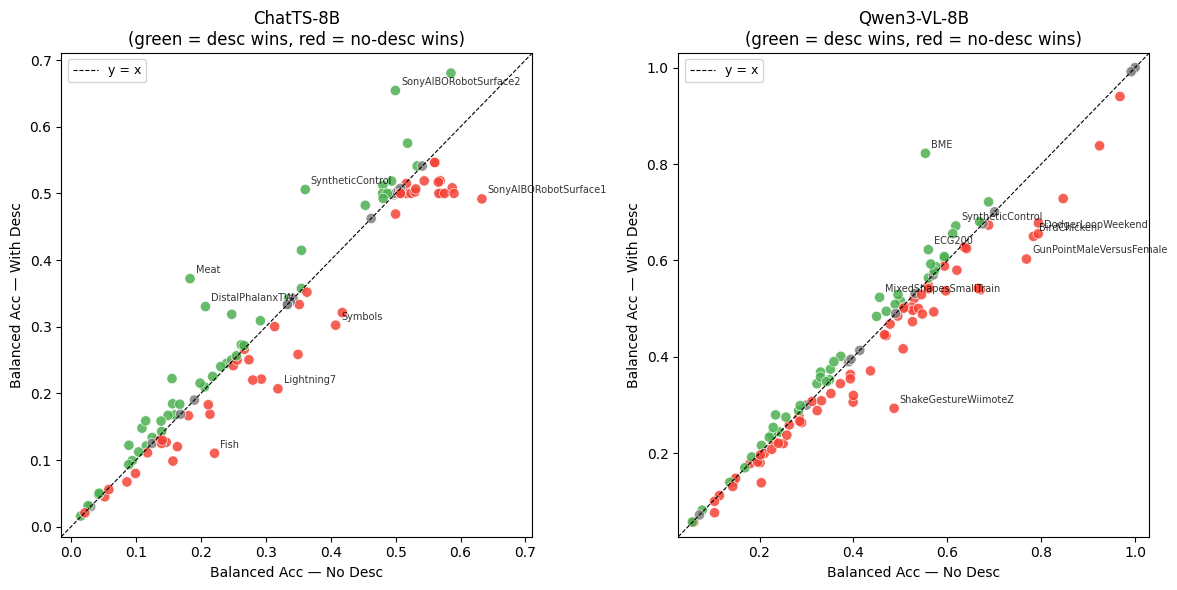

In [10]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 6))
if len(available) == 1:
    axes = [axes]

for ax, (cond_a, cond_b, model_label, _) in zip(axes, available):
    paired = tbl[[cond_a, cond_b]].dropna()
    x, y   = paired[cond_a].values, paired[cond_b].values
    colors = ["#4CAF50" if yi > xi else "#F44336" if yi < xi else "gray"
              for xi, yi in zip(x, y)]
    ax.scatter(x, y, c=colors, s=55, alpha=0.85, edgecolors="white", linewidths=0.5)
    lim = [min(x.min(), y.min()) - 0.03, max(x.max(), y.max()) + 0.03]
    ax.plot(lim, lim, "k--", linewidth=0.8, label="y = x")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"Balanced Acc — No Desc")
    ax.set_ylabel(f"Balanced Acc — With Desc")
    ax.set_title(f"{model_label}\n(green = desc wins, red = no-desc wins)")
    ax.legend(fontsize=9)
    delta_arr = y - x
    for i in list(np.argsort(delta_arr)[-4:][::-1]) + list(np.argsort(delta_arr)[:4]):
        ax.annotate(paired.index[i], (x[i], y[i]), fontsize=7, alpha=0.8,
                    xytext=(4, 4), textcoords="offset points")

plt.tight_layout()
plt.show()

### Δ vs Number of Classes

Does the description effect correlate with task difficulty (number of classes)?  
Negative Spearman ρ → descriptions are more harmful on harder tasks.

,Num Classes,Δ ChatTS (with−no),Δ QwenVL (with−no)
Task,,,
Chinatown,2,+0.000,-0.017
Coffee,2,-0.024,-0.116
BirdChicken,2,-0.017,-0.133
BeetleFly,2,+0.000,+0.017
DodgerLoopWeekend,2,-0.071,-0.138
DodgerLoopGame,2,+0.008,+0.011
DistalPhalanxOutlineCorrect,2,+0.000,-0.010
Computers,2,-0.049,-0.008
ECGFiveDays,2,+0.000,-0.010



Spearman ρ  (Num Classes ↔ Δ):
  ChatTS-8B           : ρ = +0.131,  p = 0.1517  n.s.
  Qwen3-VL-8B         : ρ = +0.134,  p = 0.1399  n.s.


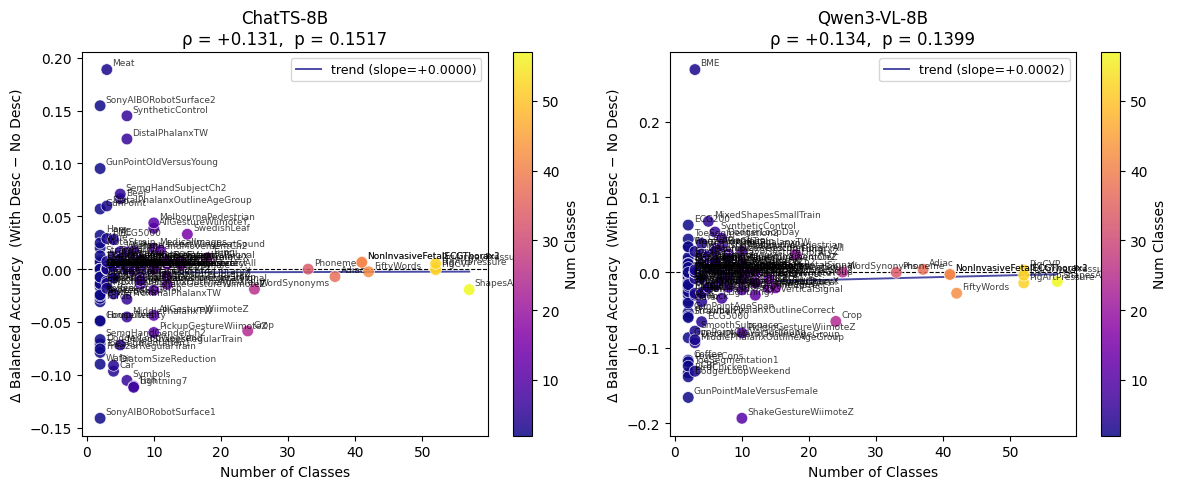

In [11]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore").copy()

n_classes = (
    finished.groupby("task")["num_of_classes"]
    .median().round().dropna().astype(int)
)
tbl["Num Classes"] = n_classes

delta_pairs = [(DELTA_CHATTS, "ChatTS-8B"), (DELTA_VL, "Qwen3-VL-8B")]
available_d = [(col, lbl) for col, lbl in delta_pairs if col in tbl.columns]

table_cols = ["Num Classes"] + [c for c, _ in available_d]
tbl_show   = tbl[table_cols].dropna(subset=["Num Classes"]).sort_values("Num Classes")

vabs = tbl_show[[c for c, _ in available_d]].abs().max().max() if available_d else 0.1
display(
    tbl_show.style
    .format({"Num Classes": "{:.0f}", **{c: "{:+.3f}" for c, _ in available_d}})
    .background_gradient(cmap="RdBu", axis=None,
                         subset=[c for c, _ in available_d], vmin=-vabs, vmax=vabs)
    .background_gradient(cmap="Blues", axis=0, subset=["Num Classes"])
    .set_caption("Δ per model vs number of classes, sorted by class count")
)

print("\nSpearman ρ  (Num Classes ↔ Δ):")
for col, model_label in available_d:
    paired_df = tbl_show[["Num Classes", col]].dropna()
    rho, p_val = spearmanr(paired_df["Num Classes"], paired_df[col])
    sig_str = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(f"  {model_label:20s}: ρ = {rho:+.3f},  p = {p_val:.4f}  {sig_str}")

fig, axes = plt.subplots(1, max(len(available_d), 1), figsize=(6 * max(len(available_d), 1), 5), sharey=False)
if len(available_d) <= 1:
    axes = [axes]

for ax, (col, model_label) in zip(axes, available_d):
    paired_df = tbl_show[["Num Classes", col]].dropna()
    x_c, y_d  = paired_df["Num Classes"].values, paired_df[col].values
    sc = ax.scatter(x_c, y_d, c=x_c, cmap="plasma", s=70, alpha=0.85,
                    edgecolors="white", linewidths=0.5, zorder=3)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    if len(x_c) > 2:
        z = np.polyfit(x_c, y_d, 1)
        xfit = np.linspace(x_c.min(), x_c.max(), 100)
        rho, p_val = spearmanr(x_c, y_d)
        ax.plot(xfit, np.polyval(z, xfit), color="navy", linewidth=1.4, alpha=0.7,
                label=f"trend (slope={z[0]:+.4f})")
        ax.set_title(f"{model_label}\nρ = {rho:+.3f},  p = {p_val:.4f}")
    ax.set_xlabel("Number of Classes")
    ax.set_ylabel("Δ Balanced Accuracy  (With Desc − No Desc)")
    ax.legend(fontsize=9)
    for i, task in enumerate(paired_df.index):
        ax.annotate(task, (x_c[i], y_d[i]), fontsize=6.5, alpha=0.75,
                    xytext=(4, 3), textcoords="offset points")
    plt.colorbar(sc, ax=ax, label="Num Classes")

plt.tight_layout()
plt.show()

## 4 · Per-Model Wilcoxon Signed-Rank Test

Paired test per model: is **With Description** significantly different from **No Description**?

In [18]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

def sig(p):
    return "*** (p<0.001)" if p < 0.001 else "** (p<0.01)" if p < 0.01 else "* (p<0.05)" if p < 0.05 else "n.s."

model_pairs_wilcox = [
    (COND_CHATTS_NO, COND_CHATTS_WITH, "ChatTS-8B"),
    (COND_VL_NO,     COND_VL_WITH,     "Qwen3-VL-8B"),
]

for cond_a, cond_b, model_label in model_pairs_wilcox:
    if cond_a not in tbl.columns or cond_b not in tbl.columns:
        print(f"{model_label}: data not available\n"); continue
    paired = tbl[[cond_a, cond_b]].dropna()
    a_vals, b_vals = paired[cond_a].values, paired[cond_b].values
    delta_vals = b_vals - a_vals

    stat_2, p_2 = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="two-sided")
    stat_g, p_g = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="greater")
    stat_l, p_l = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="less")

    print(f"{'─'*55}")
    print(f"{model_label}")
    print(f"  Paired datasets      : {len(paired)}")
    print(f"  Mean (No Desc)       : {a_vals.mean():.4f}")
    print(f"  Mean (With Desc)     : {b_vals.mean():.4f}")
    print(f"  Mean Δ (with − no)   : {delta_vals.mean():+.4f}")
    print(f"  Datasets improved    : {(delta_vals > 0).sum()} / {len(delta_vals)}  ({(delta_vals > 0).mean()*100:.1f}%)")
    print(f"  Datasets hurt        : {(delta_vals < 0).sum()} / {len(delta_vals)}  ({(delta_vals < 0).mean()*100:.1f}%)")
    print(f"  Wilcoxon two-sided   : stat={stat_2:.1f},  p={p_2:.4f}  {sig(p_2)}")
    print(f"  Wilcoxon (with>no)   : stat={stat_g:.1f},  p={p_g:.4f}  {sig(p_g)}")
    print(f"  Wilcoxon (with<no)   : stat={stat_l:.1f},  p={p_l:.4f}  {sig(p_l)}")
    print()

───────────────────────────────────────────────────────
ChatTS-8B
  Paired datasets      : 122
  Mean (No Desc)       : 0.3245
  Mean (With Desc)     : 0.3213
  Mean Δ (with − no)   : -0.0032
  Datasets improved    : 47 / 122  (38.5%)
  Datasets hurt        : 49 / 122  (40.2%)
  Wilcoxon two-sided   : stat=3258.0,  p=0.4141  n.s.
  Wilcoxon (with>no)   : stat=3258.0,  p=0.7929  n.s.
  Wilcoxon (with<no)   : stat=3258.0,  p=0.2071  n.s.

───────────────────────────────────────────────────────
Qwen3-VL-8B
  Paired datasets      : 122
  Mean (No Desc)       : 0.4322
  Mean (With Desc)     : 0.4192
  Mean Δ (with − no)   : -0.0130
  Datasets improved    : 40 / 122  (32.8%)
  Datasets hurt        : 69 / 122  (56.6%)
  Wilcoxon two-sided   : stat=2527.0,  p=0.0026  ** (p<0.01)
  Wilcoxon (with>no)   : stat=2527.0,  p=0.9987  n.s.
  Wilcoxon (with<no)   : stat=2527.0,  p=0.0013  ** (p<0.01)



## 4.5 · Cross-Model Comparison — ChatTS vs QwenVL

Direct pairwise Wilcoxon between all 4 conditions. Shows which model × desc setting is best overall.

In [19]:
tbl   = mean_p.drop(index="Macro Avg", errors="ignore")
pairs = [
    (COND_CHATTS_NO,   COND_VL_NO,       "ChatTS No Desc vs QwenVL No Desc"),
    (COND_CHATTS_WITH, COND_VL_WITH,     "ChatTS With Desc vs QwenVL With Desc"),
    (COND_CHATTS_NO,   COND_CHATTS_WITH, "ChatTS: No Desc vs With Desc"),
    (COND_VL_NO,       COND_VL_WITH,     "QwenVL: No Desc vs With Desc"),
]

print("Pairwise Wilcoxon signed-rank tests (two-sided, no correction):")
print(f"{'─'*65}")
rows = []
for cond_a, cond_b, label in pairs:
    if cond_a not in tbl.columns or cond_b not in tbl.columns:
        continue
    paired = tbl[[cond_a, cond_b]].dropna()
    a_vals, b_vals = paired[cond_a].values, paired[cond_b].values
    delta_mean = (b_vals - a_vals).mean()
    try:
        stat, p = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="two-sided")
    except ValueError:
        stat, p = np.nan, np.nan
    rows.append({"Comparison": label, "N": len(paired),
                 f"Mean({cond_a[:7]})": a_vals.mean(),
                 f"Mean({cond_b[:7]})": b_vals.mean(),
                 "Mean Δ (B−A)": delta_mean, "stat": stat, "p-value": p,
                 "Sig.": sig(p)})

df_pairs = pd.DataFrame(rows)
display(
    df_pairs.style
    .format({"Mean Δ (B−A)": "{:+.4f}", "stat": "{:.1f}", "p-value": "{:.4f}"})
    .background_gradient(cmap="RdBu", subset=["Mean Δ (B−A)"], axis=0)
    .set_caption("Pairwise Wilcoxon (two-sided) between conditions")
)

Pairwise Wilcoxon signed-rank tests (two-sided, no correction):
─────────────────────────────────────────────────────────────────


,Comparison,N,Mean(ChatTS ),Mean(QwenVL ),Mean Δ (B−A),stat,p-value,Sig.
0,ChatTS No Desc vs QwenVL No Desc,122,0.324476,0.432216,+0.1077,371.0,0.0000,*** (p<0.001)
1,ChatTS With Desc vs QwenVL With Desc,122,0.321287,0.419214,+0.0979,475.0,0.0000,*** (p<0.001)
2,ChatTS: No Desc vs With Desc,122,0.321287,nan,-0.0032,3258.0,0.4141,n.s.
3,QwenVL: No Desc vs With Desc,122,nan,0.419214,-0.0130,2527.0,0.0026,** (p<0.01)


## 5 · Critical Difference Diagram

All 4 conditions ranked via **Friedman test** followed by **pairwise Wilcoxon signed-rank
with Holm–Bonferroni correction** at α = 0.05.

Conditions connected by a horizontal bar are **not significantly different**.  
Lower average rank = better (rank 1 is best per dataset).

In [20]:
tbl      = mean_p.drop(index="Macro Avg", errors="ignore")
stat_cols = [c for c in cols if c in tbl.columns]
pivot_stat = tbl[stat_cols].dropna()

print(f"Datasets used for CD diagram: {len(pivot_stat)}")
print(f"  (dropped {len(tbl) - len(pivot_stat)} datasets with any missing condition)")

# Friedman omnibus test
groups = [pivot_stat[c].values for c in stat_cols]
friedman_stat, friedman_p = friedmanchisquare(*groups)
print(f"\nFriedman test:")
print(f"  χ² = {friedman_stat:.4f},  p = {friedman_p:.6f}  {sig(friedman_p)}")

Datasets used for CD diagram: 122
  (dropped 0 datasets with any missing condition)

Friedman test:
  χ² = 153.1529,  p = 0.000000  *** (p<0.001)


Average ranks (1 = best):
  QwenVL · No Desc              : 1.6557
  QwenVL · With Desc            : 1.9385
  ChatTS · No Desc              : 3.1680
  ChatTS · With Desc            : 3.2377

Pairwise Wilcoxon + Holm–Bonferroni (α=0.05):
  [✓ sig.]  ChatTS · With Desc  vs  QwenVL · No Desc  — p=0.0000
  [✓ sig.]  ChatTS · No Desc  vs  QwenVL · No Desc  — p=0.0000
  [✓ sig.]  ChatTS · With Desc  vs  QwenVL · With Desc  — p=0.0000
  [✓ sig.]  ChatTS · No Desc  vs  QwenVL · With Desc  — p=0.0000
  [✓ sig.]  QwenVL · No Desc  vs  QwenVL · With Desc  — p=0.0026
  [✗ n.s.]  ChatTS · No Desc  vs  ChatTS · With Desc  — p=0.4141


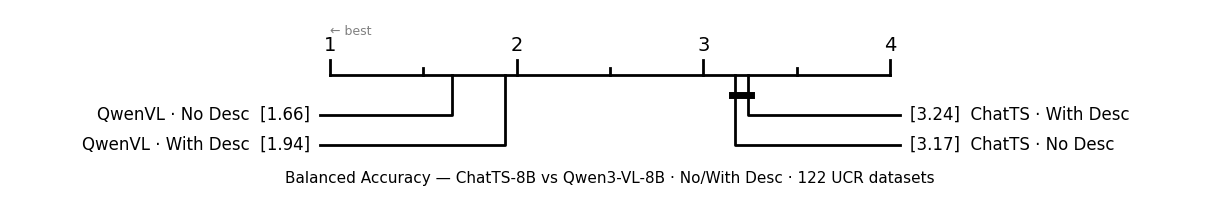

In [23]:
def graph_ranks(avranks, names, p_values, lowv=None, highv=None,
                width=9, textspace=2.5, labels=False):
    """
    CD diagram — rank 1 on LEFT (best), rank k on RIGHT (worst).
    Left-side labels = best-ranked; their arms go slightly RIGHT to rank tick.
    Right-side labels = worst-ranked; their arms go slightly LEFT to rank tick.
    No long crossing arms.
    """
    width, textspace = float(width), float(textspace)
    sums, nnames = avranks, names
    if lowv is None:
        lowv = min(1, int(math.floor(min(sums))))
    if highv is None:
        highv = max(len(avranks), int(math.ceil(max(sums))))
    cline = 0.65
    k = len(sums)
    scalewidth = width - 2 * textspace

    def rankpos(rank):
        # rank 1 → LEFT (textspace), rank highv → RIGHT (width - textspace)
        return textspace + scalewidth / (highv - lowv) * (rank - lowv)

    minnotsig = 2 * 0.2
    height = cline + ((k + 1) / 2) * 0.3 + minnotsig
    fig = plt.figure(figsize=(width, height))
    fig.set_facecolor("white")
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    hf, wf = 1.0 / height, 1.0 / width
    ax.plot([0, 1], [0, 1], c="w")
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)

    def line(pts, color="k", **kw):
        ax.plot([wf * p[0] for p in pts], [hf * p[1] for p in pts], color=color, **kw)

    def text(x, y, s, **kw):
        ax.text(wf * x, hf * y, s, **kw)

    # Axis line
    line([(textspace, cline), (width - textspace, cline)], linewidth=2)

    # Ticks
    tick = None
    for a in list(np.arange(lowv, highv, 0.5)) + [highv]:
        tick = 0.15 if a != int(a) else 0.3
        line([(rankpos(a), cline - tick / 2), (rankpos(a), cline)], linewidth=2)
    for a in range(lowv, highv + 1):
        text(rankpos(a), cline - tick / 2 - 0.05, str(a),
             ha="center", va="bottom", size=14)

    # "← best" label on axis
    text(textspace, cline - tick / 2 - 0.22, "← best",
         ha="left", va="bottom", size=9, color="gray")

    space = 0.3
    # Left side: best-ranked (lowest rank numbers) — short arm going slightly right
    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsig + i * space
        line([(rankpos(sums[i]), cline), (rankpos(sums[i]), chei),
              (textspace - 0.1, chei)], linewidth=2)
        label = f"{nnames[i]}  [{sums[i]:.2f}]" if labels else nnames[i]
        text(textspace - 0.2, chei, label, ha="right", va="center", size=12)

    # Right side: worst-ranked (highest rank numbers) — short arm going slightly left
    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsig + (k - i - 1) * space
        line([(rankpos(sums[i]), cline), (rankpos(sums[i]), chei),
              (textspace + scalewidth + 0.1, chei)], linewidth=2)
        label = f"[{sums[i]:.2f}]  {nnames[i]}" if labels else nnames[i]
        text(textspace + scalewidth + 0.2, chei, label, ha="left", va="center", size=12)

    # Non-significant clique bars (below axis)
    m = len(nnames)
    g_data = np.zeros((m, m), dtype=np.int64)
    for p in p_values:
        if not p[3]:
            i = list(nnames).index(p[0])
            j = list(nnames).index(p[1])
            g_data[min(i, j), max(i, j)] = 1
    start = cline + 0.2
    for clq in networkx.find_cliques(networkx.Graph(g_data)):
        if len(clq) == 1:
            continue
        r_lo = rankpos(sums[min(clq)])
        r_hi = rankpos(sums[max(clq)])
        line([(r_lo - 0.03, start), (r_hi + 0.03, start)], linewidth=5)
        start += 0.12
    return fig


def draw_cd_diagram(df_perf, alpha=0.05, title=None, labels=True):
    """Friedman rank → pairwise Wilcoxon → Holm correction → CD diagram."""
    classifiers = df_perf["classifier_name"].unique().tolist()

    # Pairwise Wilcoxon
    p_values = []
    for i in range(len(classifiers) - 1):
        for j in range(i + 1, len(classifiers)):
            c1, c2 = classifiers[i], classifiers[j]
            d1 = df_perf[df_perf["classifier_name"] == c1].set_index("dataset_name")["accuracy"]
            d2 = df_perf[df_perf["classifier_name"] == c2].set_index("dataset_name")["accuracy"]
            common = d1.index.intersection(d2.index)
            if len(common) < 2:
                continue
            try:
                p = wilcoxon(d1[common].values, d2[common].values, zero_method="pratt")[1]
            except ValueError:
                p = 1.0
            p_values.append([c1, c2, p, False])

    # Holm–Bonferroni step-down correction
    p_values.sort(key=lambda x: x[2])
    m_pairs = len(p_values)
    for i, pv in enumerate(p_values):
        pv[3] = pv[2] <= alpha / (m_pairs - i)

    # Average ranks (rank 1 = best within each dataset)
    pivot = df_perf.pivot(index="dataset_name", columns="classifier_name", values="accuracy")
    avg_ranks = pivot.rank(axis=1, ascending=False).mean(axis=0).sort_values(ascending=True)

    print("Average ranks (1 = best):")
    for name, rank in avg_ranks.items():
        print(f"  {name:30s}: {rank:.4f}")

    print(f"\nPairwise Wilcoxon + Holm–Bonferroni (α={alpha}):")
    for pv in p_values:
        marker = "✓ sig." if pv[3] else "✗ n.s."
        print(f"  [{marker}]  {pv[0]}  vs  {pv[1]}  — p={pv[2]:.4f}")

    fig = graph_ranks(
        avg_ranks.values,
        avg_ranks.index.values,
        [tuple(p) for p in p_values],
        width=12, textspace=3.2, labels=labels
    )
    if title:
        fig.text(0.5, 0.02, title, ha="center", va="bottom", fontsize=11)
    plt.show()


df_perf = (
    pivot_stat.reset_index()
    .melt(id_vars="Task", var_name="classifier_name", value_name="accuracy")
    .rename(columns={"Task": "dataset_name"})
)

draw_cd_diagram(
    df_perf=df_perf,
    alpha=0.05,
    title="Balanced Accuracy — ChatTS-8B vs Qwen3-VL-8B · No/With Desc · 122 UCR datasets",
    labels=True
)

## 6 · Results by Dataset Category

,N Datasets,ChatTS · No Desc,ChatTS · With Desc,QwenVL · No Desc,QwenVL · With Desc,Δ ChatTS (with−no),Δ QwenVL (with−no)
Category,,,,,,,
ECG/Medical,12,0.201,0.200,0.291,0.282,-0.001,-0.009
Image/Shape,33,0.304,0.293,0.397,0.382,-0.011,-0.015
Motion/HAR,23,0.272,0.271,0.370,0.343,-0.001,-0.027
Sensor/Device,41,0.410,0.400,0.535,0.534,-0.010,-0.002
Simulated,6,0.248,0.273,0.400,0.389,+0.024,-0.011
Spectrographic,7,0.368,0.410,0.465,0.436,+0.042,-0.030


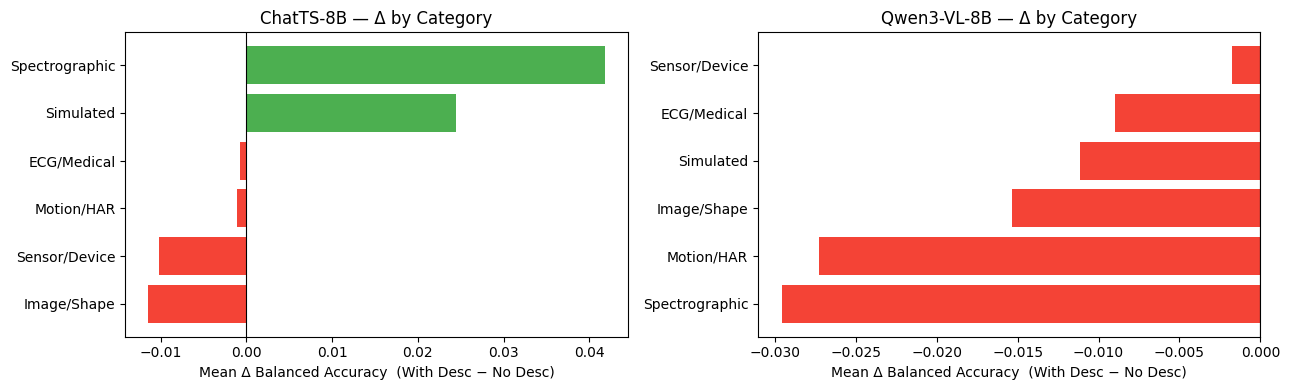

In [16]:
CATEGORY_MAP = {
    # Image / Shape
    "Adiac": "Image/Shape", "ArrowHead": "Image/Shape", "BeetleFly": "Image/Shape",
    "BirdChicken": "Image/Shape", "DiatomSizeReduction": "Image/Shape",
    "DistalPhalanxOutlineAgeGroup": "Image/Shape", "DistalPhalanxOutlineCorrect": "Image/Shape",
    "DistalPhalanxTW": "Image/Shape", "FaceAll": "Image/Shape", "FaceFour": "Image/Shape",
    "FacesUCR": "Image/Shape", "FiftyWords": "Image/Shape", "Fish": "Image/Shape",
    "HandOutlines": "Image/Shape", "Herring": "Image/Shape", "MedicalImages": "Image/Shape",
    "MiddlePhalanxOutlineAgeGroup": "Image/Shape", "MiddlePhalanxOutlineCorrect": "Image/Shape",
    "MiddlePhalanxTW": "Image/Shape", "MixedShapesRegularTrain": "Image/Shape",
    "MixedShapesSmallTrain": "Image/Shape", "OSULeaf": "Image/Shape",
    "PhalangesOutlinesCorrect": "Image/Shape", "ProximalPhalanxOutlineAgeGroup": "Image/Shape",
    "ProximalPhalanxOutlineCorrect": "Image/Shape", "ProximalPhalanxTW": "Image/Shape",
    "ShapesAll": "Image/Shape", "ShapeletSim": "Image/Shape", "SwedishLeaf": "Image/Shape",
    "Symbols": "Image/Shape", "WordSynonyms": "Image/Shape", "Yoga": "Image/Shape",
    "Crop": "Image/Shape",
    # Sensor / Device
    "ACSF1": "Sensor/Device", "BME": "Sensor/Device", "Car": "Sensor/Device",
    "Chinatown": "Sensor/Device", "ChlorineConcentration": "Sensor/Device",
    "Computers": "Sensor/Device", "DodgerLoopDay": "Sensor/Device",
    "DodgerLoopGame": "Sensor/Device", "DodgerLoopWeekend": "Sensor/Device",
    "Earthquakes": "Sensor/Device", "ElectricDevices": "Sensor/Device",
    "EthanolLevel": "Sensor/Device", "FordA": "Sensor/Device", "FordB": "Sensor/Device",
    "FreezerRegularTrain": "Sensor/Device", "FreezerSmallTrain": "Sensor/Device",
    "HouseTwenty": "Sensor/Device", "InsectEPGRegularTrain": "Sensor/Device",
    "InsectEPGSmallTrain": "Sensor/Device", "InsectWingbeatSound": "Sensor/Device",
    "ItalyPowerDemand": "Sensor/Device", "LargeKitchenAppliances": "Sensor/Device",
    "Lightning2": "Sensor/Device", "Lightning7": "Sensor/Device",
    "MelbournePedestrian": "Sensor/Device", "MoteStrain": "Sensor/Device",
    "Plane": "Sensor/Device", "PowerCons": "Sensor/Device",
    "RefrigerationDevices": "Sensor/Device", "Rock": "Sensor/Device",
    "ScreenType": "Sensor/Device", "SemgHandGenderCh2": "Sensor/Device",
    "SemgHandMovementCh2": "Sensor/Device", "SemgHandSubjectCh2": "Sensor/Device",
    "SmallKitchenAppliances": "Sensor/Device", "SmoothSubspace": "Sensor/Device",
    "SonyAIBORobotSurface1": "Sensor/Device", "SonyAIBORobotSurface2": "Sensor/Device",
    "StarLightCurves": "Sensor/Device", "Trace": "Sensor/Device", "Wafer": "Sensor/Device",
    # Motion / HAR
    "AllGestureWiimoteX": "Motion/HAR", "AllGestureWiimoteY": "Motion/HAR",
    "AllGestureWiimoteZ": "Motion/HAR", "CricketX": "Motion/HAR",
    "CricketY": "Motion/HAR", "CricketZ": "Motion/HAR", "Fungi": "Motion/HAR",
    "GunPoint": "Motion/HAR", "GunPointAgeSpan": "Motion/HAR",
    "GunPointMaleVersusFemale": "Motion/HAR", "GunPointOldVersusYoung": "Motion/HAR",
    "Haptics": "Motion/HAR", "InlineSkate": "Motion/HAR",
    "PickupGestureWiimoteZ": "Motion/HAR", "ShakeGestureWiimoteZ": "Motion/HAR",
    "ToeSegmentation1": "Motion/HAR", "ToeSegmentation2": "Motion/HAR",
    "UWaveGestureLibraryAll": "Motion/HAR", "UWaveGestureLibraryX": "Motion/HAR",
    "UWaveGestureLibraryY": "Motion/HAR", "UWaveGestureLibraryZ": "Motion/HAR",
    "Worms": "Motion/HAR", "WormsTwoClass": "Motion/HAR",
    # ECG / Medical
    "CinCECGTorso": "ECG/Medical", "ECG200": "ECG/Medical", "ECG5000": "ECG/Medical",
    "ECGFiveDays": "ECG/Medical", "EOGHorizontalSignal": "ECG/Medical",
    "EOGVerticalSignal": "ECG/Medical", "NonInvasiveFetalECGThorax1": "ECG/Medical",
    "NonInvasiveFetalECGThorax2": "ECG/Medical", "PigAirwayPressure": "ECG/Medical",
    "PigArtPressure": "ECG/Medical", "PigCVP": "ECG/Medical", "TwoLeadECG": "ECG/Medical",
    # Spectrographic
    "Beef": "Spectrographic", "Coffee": "Spectrographic", "Ham": "Spectrographic",
    "Meat": "Spectrographic", "OliveOil": "Spectrographic", "Strawberry": "Spectrographic",
    "Wine": "Spectrographic",
    # Simulated
    "CBF": "Simulated", "Mallat": "Simulated", "Phoneme": "Simulated",
    "SyntheticControl": "Simulated", "TwoPatterns": "Simulated", "UMD": "Simulated",
}

tbl = mean_p.drop(index="Macro Avg", errors="ignore").copy()
tbl["Category"] = tbl.index.map(lambda t: CATEGORY_MAP.get(t, "Other"))

cat_cols = cols + DELTA_COLS
cat_summary = tbl.groupby("Category")[cat_cols].mean()
cat_counts  = tbl.groupby("Category").size().rename("N Datasets")
cat_summary = pd.concat([cat_counts, cat_summary], axis=1)

vabs = cat_summary[DELTA_COLS].abs().max().max()
display(
    cat_summary.style
    .format({"N Datasets": "{:.0f}", **{c: "{:.3f}" for c in cols},
             **{c: "{:+.3f}" for c in DELTA_COLS}})
    .background_gradient(cmap="RdYlGn", axis=None, subset=cols, vmin=0, vmax=1)
    .background_gradient(cmap="RdBu",   axis=None, subset=DELTA_COLS, vmin=-vabs, vmax=vabs)
    .set_caption("Mean Balanced Accuracy & Δ by Dataset Category")
)

# Bar chart: mean Δ by category for each model
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (dcol, model_label) in zip(axes, [(DELTA_CHATTS, "ChatTS-8B"), (DELTA_VL, "Qwen3-VL-8B")]):
    cat_delta = tbl.groupby("Category")[dcol].mean().sort_values()
    bar_c     = ["#4CAF50" if v >= 0 else "#F44336" for v in cat_delta]
    ax.barh(cat_delta.index, cat_delta.values, color=bar_c)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Mean Δ Balanced Accuracy  (With Desc − No Desc)")
    ax.set_title(f"{model_label} — Δ by Category")

plt.tight_layout()
plt.show()

## 7 · Summary

In [17]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

print("=" * 60)
print(f"Experiment  : {EXP_ID}")
print(f"Models      : ChatTS-8B  |  Qwen3-VL-8B")
print(f"Datasets    : {len(tbl)} / 122")
print(f"Seeds       : {N_SEEDS}  (0, 3, 6)")
print("=" * 60)

print("\nMacro Balanced Accuracy:")
for c in cols:
    print(f"  {c:30s}: {mean_p.loc['Macro Avg', c]:.4f}")

print("\nDescription effect summary:")
for cond_a, cond_b, model_label, dcol in [
        (COND_CHATTS_NO, COND_CHATTS_WITH, "ChatTS-8B",   DELTA_CHATTS),
        (COND_VL_NO,     COND_VL_WITH,     "QwenVL-8B",   DELTA_VL)]:
    if dcol not in tbl.columns:
        continue
    delta = tbl[dcol].dropna()
    print(f"\n  {model_label}:")
    print(f"    Mean Δ            : {delta.mean():+.4f}")
    print(f"    Datasets improved : {(delta > 0).sum()} / {len(delta)}  ({(delta > 0).mean()*100:.1f}%)")
    print(f"    Datasets hurt     : {(delta < 0).sum()} / {len(delta)}  ({(delta < 0).mean()*100:.1f}%)")

print("\nTop 5 datasets where description helps most (either model):")
best_delta = tbl[DELTA_COLS].max(axis=1).nlargest(5)
for task, val in best_delta.items():
    row = tbl.loc[task, DELTA_COLS]
    print(f"  {task:35s}: ChatTS {row[DELTA_CHATTS]:+.3f}  |  QwenVL {row[DELTA_VL]:+.3f}")

print("\nTop 5 datasets where description hurts most (either model):")
worst_delta = tbl[DELTA_COLS].min(axis=1).nsmallest(5)
for task, val in worst_delta.items():
    row = tbl.loc[task, DELTA_COLS]
    print(f"  {task:35s}: ChatTS {row[DELTA_CHATTS]:+.3f}  |  QwenVL {row[DELTA_VL]:+.3f}")

Experiment  : desc_ablation_full
Models      : ChatTS-8B  |  Qwen3-VL-8B
Datasets    : 122 / 122
Seeds       : 3  (0, 3, 6)

Macro Balanced Accuracy:
  ChatTS · No Desc              : 0.3245
  ChatTS · With Desc            : 0.3213
  QwenVL · No Desc              : 0.4322
  QwenVL · With Desc            : 0.4192

Description effect summary:

  ChatTS-8B:
    Mean Δ            : -0.0032
    Datasets improved : 47 / 122  (38.5%)
    Datasets hurt     : 49 / 122  (40.2%)

  QwenVL-8B:
    Mean Δ            : -0.0130
    Datasets improved : 40 / 122  (32.8%)
    Datasets hurt     : 69 / 122  (56.6%)

Top 5 datasets where description helps most (either model):
  BME                                : ChatTS +0.029  |  QwenVL +0.269
  Meat                               : ChatTS +0.189  |  QwenVL -0.028
  SonyAIBORobotSurface2              : ChatTS +0.155  |  QwenVL +0.007
  SyntheticControl                   : ChatTS +0.145  |  QwenVL +0.054
  DistalPhalanxTW                    : ChatTS +0.123